In [1]:
# pip install --upgrade ras-commander

**For Development**: run this notebook from the repository root with the local source tree on `PYTHONPATH`.

PowerShell example:

```powershell
$env:PYTHONPATH=(Get-Location).Path
conda run -n symphony-dev jupyter nbconvert --to notebook --execute examples/314_reference_line_generation.ipynb --inplace
```


# Automated Reference Line Generation

This notebook demonstrates the CLB-321 reference-line workflow on a real HEC-RAS 2D example project. It generates transverse reference lines from a named longitudinal profile, plots the generated lines on DEM hillshade terrain context, writes them to a `.g##` geometry file through `GeomReferenceFeatures`, and samples terrain profiles along the generated reference lines.


In [2]:
from pathlib import Path
import logging
import shutil
import warnings

import geopandas as gpd
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import from_bounds
from shapely.geometry import LineString

from ras_commander import (
    GeomPreprocessor,
    GeomReferenceFeatures,
    RasExamples,
    RasMap,
    init_ras_project,
    ras,
)
from ras_commander.hdf import HdfBndry, HdfMesh

warnings.filterwarnings("ignore", category=UserWarning)
logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("ras_commander").setLevel(logging.WARNING)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 120


## Parameters

In [3]:
PROJECT_NAME = "BaldEagleCrkMulti2D"
PROJECT_VERSION = "7.0"
TARGET_GEOMETRY_NUMBER = "01"
TARGET_PLAN_NUMBER = "01"
PROFILE_NAME = "Bald Eagle profile"

SPACING_FT = 10000.0
REFERENCE_LINE_LENGTH_FT = 6500.0
START_STATION_FT = 5000.0
END_STATION_FT = 70000.0
N_PROFILE_SAMPLES = 90

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
OUTPUT_ROOT = REPO_ROOT / "working" / "314_reference_line_generation"
PROJECT_OUTPUT = OUTPUT_ROOT / "example_projects"

if OUTPUT_ROOT.exists():
    shutil.rmtree(OUTPUT_ROOT)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Working folder: {OUTPUT_ROOT}")
print(f"Project extraction folder: {PROJECT_OUTPUT}")


Working folder: C:\GH\symphony-workspaces\ras-commander\CLB-321\working\314_reference_line_generation
Project extraction folder: C:\GH\symphony-workspaces\ras-commander\CLB-321\working\314_reference_line_generation\example_projects


## Extract And Inspect The Example Project

In [4]:
project_path = RasExamples.extract_project(
    PROJECT_NAME,
    output_path=PROJECT_OUTPUT,
    suffix="314_reference_lines",
)
init_ras_project(project_path, PROJECT_VERSION)

geom_row = ras.geom_df[
    ras.geom_df["geom_number"].astype(str).str.zfill(2).eq(TARGET_GEOMETRY_NUMBER)
].iloc[0]
geom_file = Path(geom_row["full_path"])
geom_hdf = Path(geom_row["hdf_path"])
storage_area = geom_row["mesh_area_names"][0]

terrain_layers = RasMap.list_terrain_layers(project_path)
terrain_hdf = Path(terrain_layers.iloc[0]["resolved_path"])
dem_candidates = sorted(terrain_hdf.parent.glob("*.dtm_20ft.tif")) or sorted(
    terrain_hdf.parent.glob("*.tif")
)
dem_path = dem_candidates[0]

summary = pd.DataFrame(
    [
        {"item": "project", "value": str(project_path)},
        {"item": "geometry", "value": geom_file.name},
        {"item": "compiled_geometry_hdf", "value": geom_hdf.name},
        {"item": "target_plan", "value": f"p{TARGET_PLAN_NUMBER}"},
        {"item": "storage_area", "value": storage_area},
        {"item": "terrain_layer", "value": terrain_layers.iloc[0]["name"]},
        {"item": "dem", "value": dem_path.name},
    ]
)
display(summary)


,item,value
0,project,C:\GH\symphony-workspaces\ras-commander\CLB-32...
1,geometry,BaldEagleDamBrk.g01
2,compiled_geometry_hdf,BaldEagleDamBrk.g01.hdf
3,target_plan,p01
4,storage_area,BaldEagleCr
5,terrain_layer,Terrain50
6,dem,Terrain50.dtm_20ft.tif


## Create A Named Longitudinal Profile

In [5]:
mesh_areas = HdfMesh.get_mesh_areas(geom_hdf)
mesh_area = mesh_areas.loc[mesh_areas["mesh_name"].eq(storage_area)].iloc[0]

profile_line = LineString(
    [
        (2011000.0, 324000.0),
        (2078000.0, 365000.0),
    ]
)
profile_gdf = gpd.GeoDataFrame(
    {"Name": [PROFILE_NAME], "geometry": [profile_line]},
    geometry="geometry",
    crs=mesh_areas.crs,
)

print(f"Profile length: {profile_line.length:,.0f} ft")
print(f"Mesh CRS: {mesh_areas.crs}")


Profile length: 78,549 ft
Mesh CRS: EPSG:2271


## Generate Reference Lines

In [6]:
generated_lines = GeomReferenceFeatures.generate_reference_lines_from_longitudinal_line(
    profile_gdf,
    longitudinal_line_name=PROFILE_NAME,
    spacing=SPACING_FT,
    line_length=REFERENCE_LINE_LENGTH_FT,
    start_station=START_STATION_FT,
    end_station=END_STATION_FT,
    name_template="AutoRL_{index:02d}_{station_int}",
    storage_area=storage_area,
)

reference_gdf = gpd.GeoDataFrame(
    [
        {
            "Name": line["name"],
            "source_name": line["source_name"],
            "station_ft": line["station"],
            "orientation": line["orientation"],
            "orientation_angle": line["orientation_angle"],
            "geometry": LineString(line["coordinates"]),
        }
        for line in generated_lines
    ],
    geometry="geometry",
    crs=mesh_areas.crs,
)

review_table = reference_gdf.drop(columns="geometry").copy()
review_table["station_ft"] = review_table["station_ft"].round(1)
review_table["orientation_angle"] = review_table["orientation_angle"].round(2)
display(review_table)


,Name,source_name,station_ft,orientation,orientation_angle
0,AutoRL_01_5000,Bald Eagle profile,5000.0,normal,121.46
1,AutoRL_02_15000,Bald Eagle profile,15000.0,normal,121.46
2,AutoRL_03_25000,Bald Eagle profile,25000.0,normal,121.46
3,AutoRL_04_35000,Bald Eagle profile,35000.0,normal,121.46
4,AutoRL_05_45000,Bald Eagle profile,45000.0,normal,121.46
5,AutoRL_06_55000,Bald Eagle profile,55000.0,normal,121.46
6,AutoRL_07_65000,Bald Eagle profile,65000.0,normal,121.46


## Plot Generated Lines On Terrain

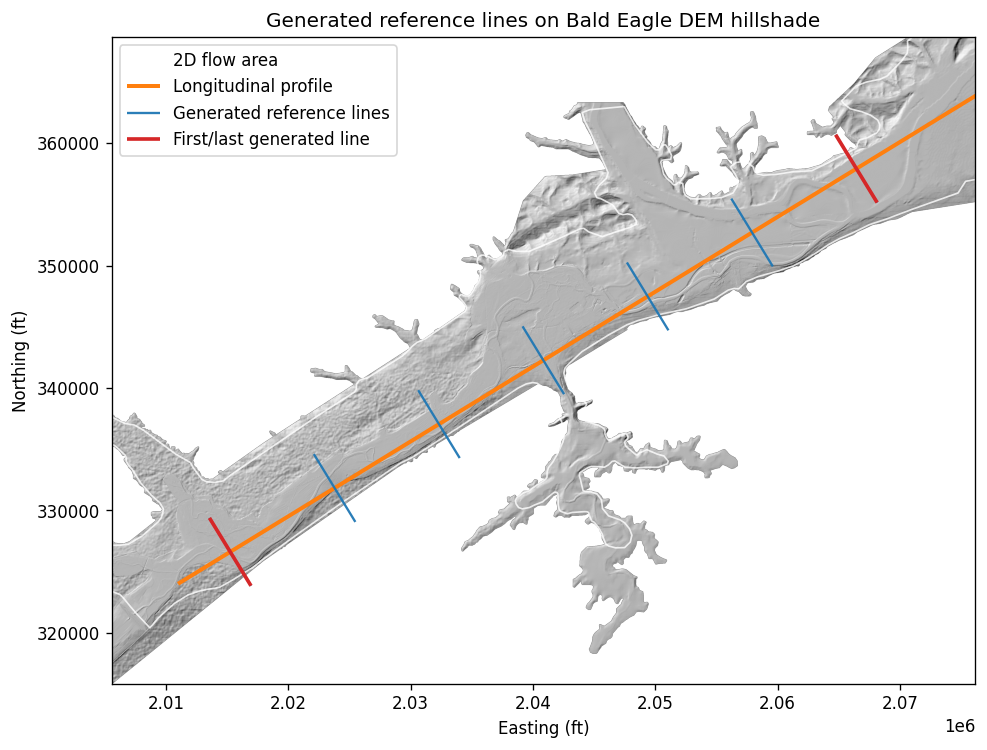

In [7]:
def hillshade(elevation, x_resolution, y_resolution, azimuth=315, altitude=45):
    data = np.asarray(elevation.filled(np.nan), dtype=float)
    dx, dy = np.gradient(data, x_resolution, y_resolution)
    slope = np.pi / 2.0 - np.arctan(np.hypot(dx, dy))
    aspect = np.arctan2(-dx, dy)
    azimuth_rad = np.deg2rad(360.0 - azimuth + 90.0)
    altitude_rad = np.deg2rad(altitude)
    shaded = (
        np.sin(altitude_rad) * np.sin(slope)
        + np.cos(altitude_rad) * np.cos(slope) * np.cos(azimuth_rad - aspect)
    )
    return np.clip(shaded, 0.0, 1.0)

bounds = reference_gdf.total_bounds
pad = 8000.0
plot_bounds = (
    bounds[0] - pad,
    bounds[1] - pad,
    bounds[2] + pad,
    bounds[3] + pad,
)

with rasterio.open(dem_path) as src:
    window = from_bounds(*plot_bounds, transform=src.transform)
    window = window.round_offsets().round_lengths()
    dem = src.read(1, window=window, masked=True)
    transform = src.window_transform(window)
    extent = (
        transform.c,
        transform.c + transform.a * dem.shape[1],
        transform.f + transform.e * dem.shape[0],
        transform.f,
    )
    shade = hillshade(dem, abs(transform.a), abs(transform.e))

fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(shade, extent=extent, cmap="gray", origin="upper")
mesh_areas.boundary.plot(ax=ax, color="white", linewidth=1.0, alpha=0.8, label="2D flow area")
profile_gdf.plot(ax=ax, color="tab:orange", linewidth=2.4, label="Longitudinal profile")
reference_gdf.plot(ax=ax, color="tab:blue", linewidth=1.4, alpha=0.95, label="Generated reference lines")
reference_gdf.iloc[[0, -1]].plot(ax=ax, color="tab:red", linewidth=2.2, label="First/last generated line")
ax.set_xlim(plot_bounds[0], plot_bounds[2])
ax.set_ylim(plot_bounds[1], plot_bounds[3])
ax.set_aspect("equal")
ax.set_title("Generated reference lines on Bald Eagle DEM hillshade")
ax.set_xlabel("Easting (ft)")
ax.set_ylabel("Northing (ft)")
ax.legend(loc="upper left")
plt.show()


## Write And Round-Trip Through Plain Text Geometry

In [8]:
inserted_count = GeomReferenceFeatures.add_reference_lines_from_longitudinal_line(
    geom_file,
    profile_gdf,
    storage_area=storage_area,
    longitudinal_line_name=PROFILE_NAME,
    spacing=SPACING_FT,
    line_length=REFERENCE_LINE_LENGTH_FT,
    start_station=START_STATION_FT,
    end_station=END_STATION_FT,
    name_template="AutoRL_{index:02d}_{station_int}",
)

parsed_lines = GeomReferenceFeatures.get_reference_lines(geom_file)
generated_names = {line["name"] for line in generated_lines}
roundtrip_lines = [line for line in parsed_lines if line["name"] in generated_names]

print(f"Inserted reference lines: {inserted_count}")
print(f"Parsed generated reference lines from {geom_file.name}: {len(roundtrip_lines)}")
print(f"Backup geometry file exists: {Path(str(geom_file) + '.bak').exists()}")

display(pd.DataFrame(roundtrip_lines).drop(columns="coordinates"))


Inserted reference lines: 7
Parsed generated reference lines from BaldEagleDamBrk.g01: 7
Backup geometry file exists: True


,name,storage_area
0,AutoRL_01_5000,BaldEagleCr
1,AutoRL_02_15000,BaldEagleCr
2,AutoRL_03_25000,BaldEagleCr
3,AutoRL_04_35000,BaldEagleCr
4,AutoRL_05_45000,BaldEagleCr
5,AutoRL_06_55000,BaldEagleCr
6,AutoRL_07_65000,BaldEagleCr


## HDF Reference-Line Schema Check

In [9]:
fixture_hdf = OUTPUT_ROOT / "generated_reference_lines_fixture.hdf"
attr_dtype = np.dtype([("Name", "S40"), ("SA-2D", "S32"), ("Type", "S24")])
attributes = np.array(
    [(line["name"].encode("utf-8"), storage_area.encode("utf-8"), b"Reference Line") for line in generated_lines],
    dtype=attr_dtype,
)
points = np.array([pt for line in generated_lines for pt in line["coordinates"]], dtype=np.float64)
info = np.array([(idx * 2, 2, idx, 1) for idx in range(len(generated_lines))], dtype=np.int32)
parts = np.array([(idx * 2, 2) for idx in range(len(generated_lines))], dtype=np.int32)

with rasterio.open(dem_path) as src:
    projection_wkt = src.crs.to_wkt()

with h5py.File(fixture_hdf, "w") as hdf:
    hdf.attrs["Projection"] = projection_wkt
    group = hdf.create_group("Geometry/Reference Lines")
    group.create_dataset("Attributes", data=attributes)
    group.create_dataset("Polyline Info", data=info)
    group.create_dataset("Polyline Parts", data=parts)
    group.create_dataset("Polyline Points", data=points)

hdf_reference_lines = HdfBndry.get_reference_lines(fixture_hdf, mesh_name=storage_area)
print(f"HdfBndry reference lines read from fixture: {len(hdf_reference_lines)}")
display(hdf_reference_lines[["Name", "mesh_name", "Type"]])


HdfBndry reference lines read from fixture: 7


,Name,mesh_name,Type
0,AutoRL_01_5000,BaldEagleCr,Reference Line
1,AutoRL_02_15000,BaldEagleCr,Reference Line
2,AutoRL_03_25000,BaldEagleCr,Reference Line
3,AutoRL_04_35000,BaldEagleCr,Reference Line
4,AutoRL_05_45000,BaldEagleCr,Reference Line
5,AutoRL_06_55000,BaldEagleCr,Reference Line
6,AutoRL_07_65000,BaldEagleCr,Reference Line


## Sample Terrain Profiles Along Reference Lines

,Name,samples,valid_samples,min_elevation_ft,max_elevation_ft,relief_ft
0,AutoRL_01_5000,90,76,572.47,742.50,170.03
1,AutoRL_02_15000,90,66,564.03,818.81,254.78
2,AutoRL_03_25000,90,62,556.38,735.69,179.31
3,AutoRL_04_35000,90,90,563.97,586.00,22.03
4,AutoRL_05_45000,90,71,538.62,711.06,172.44
5,AutoRL_06_55000,90,90,533.12,641.53,108.41
6,AutoRL_07_65000,90,68,539.94,702.94,163.00


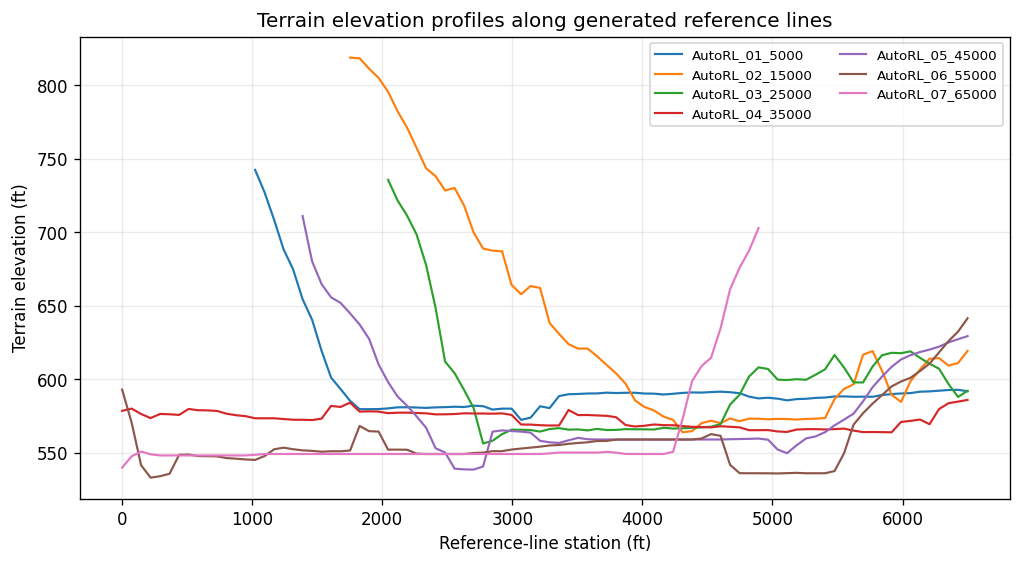

In [10]:
def sample_terrain_profile(line, raster_path, n_samples=N_PROFILE_SAMPLES):
    distances = np.linspace(0.0, line.length, n_samples)
    points = [line.interpolate(distance) for distance in distances]
    coords = [(point.x, point.y) for point in points]
    with rasterio.open(raster_path) as src:
        values = np.array([float(sample[0]) for sample in src.sample(coords)], dtype=float)
        if src.nodata is not None:
            values[np.isclose(values, src.nodata)] = np.nan
    return pd.DataFrame(
        {
            "station_ft": distances,
            "elevation_ft": values,
        }
    )

profile_tables = {}
profile_summary_rows = []
for _, row in reference_gdf.iterrows():
    table = sample_terrain_profile(row.geometry, dem_path)
    profile_tables[row["Name"]] = table
    valid = table["elevation_ft"].dropna()
    profile_summary_rows.append(
        {
            "Name": row["Name"],
            "samples": len(table),
            "valid_samples": len(valid),
            "min_elevation_ft": valid.min() if len(valid) else np.nan,
            "max_elevation_ft": valid.max() if len(valid) else np.nan,
            "relief_ft": valid.max() - valid.min() if len(valid) else np.nan,
        }
    )

profile_summary = pd.DataFrame(profile_summary_rows)
for column in ["min_elevation_ft", "max_elevation_ft", "relief_ft"]:
    profile_summary[column] = profile_summary[column].round(2)

display(profile_summary)

fig, ax = plt.subplots(figsize=(10, 5))
for name, table in profile_tables.items():
    ax.plot(table["station_ft"], table["elevation_ft"], linewidth=1.3, label=name)
ax.set_title("Terrain elevation profiles along generated reference lines")
ax.set_xlabel("Reference-line station (ft)")
ax.set_ylabel("Terrain elevation (ft)")
ax.grid(True, alpha=0.25)
ax.legend(ncol=2, fontsize=8)
plt.show()


## Optional Geometry Preprocessor Round-Trip

In [11]:
RUN_GEOMETRY_PREPROCESSOR = False

if RUN_GEOMETRY_PREPROCESSOR:
    if geom_hdf.exists():
        geom_hdf.unlink()
    for c_file in project_path.glob(f"{ras.project_name}.c{TARGET_GEOMETRY_NUMBER}"):
        c_file.unlink()

    preprocess_result = GeomPreprocessor.run_geometry_preprocessor(
        TARGET_PLAN_NUMBER,
        max_wait=600,
        clear_geompre=True,
        geometry_only=True,
    )
    print(preprocess_result)
    if geom_hdf.exists():
        compiled_lines = HdfBndry.get_reference_lines(geom_hdf, mesh_name=storage_area)
        display(compiled_lines[["Name", "mesh_name", "Type"]])
    else:
        print(f"Compiled geometry HDF was not created: {geom_hdf}")
else:
    print("Skipped HEC-RAS geometry preprocessing. Set RUN_GEOMETRY_PREPROCESSOR = True for a local compiled-HDF check.")


Skipped HEC-RAS geometry preprocessing. Set RUN_GEOMETRY_PREPROCESSOR = True for a local compiled-HDF check.


## Result

In [12]:
result_summary = pd.DataFrame(
    [
        {"check": "generated_reference_lines", "value": len(generated_lines)},
        {"check": "plain_text_roundtrip", "value": len(roundtrip_lines)},
        {"check": "hdf_schema_roundtrip", "value": len(hdf_reference_lines)},
        {"check": "profile_tables", "value": len(profile_tables)},
    ]
)
display(result_summary)


,check,value
0,generated_reference_lines,7
1,plain_text_roundtrip,7
2,hdf_schema_roundtrip,7
3,profile_tables,7
